# Constat Demo: HR Raise Analysis

This notebook demonstrates a complete HR raise analysis workflow using Constat's
Jupyter magics interface. It connects to a running Constat server, analyzes
employee performance data, generates raise recommendations, and creates
personalized email communications.

## Prerequisites

1. Start the server: `constat serve -c demo/config.yaml`
2. Install the Jupyter extension: `pip install -e constat-jupyter`
3. If auth is enabled, run `%constat login` below before connecting

In [1]:
%load_ext constat_jupyter

In [2]:
%constat login

In [3]:
%constat connect sales-analytics,hr-reporting

## Step 1: Generate Raise Recommendations

Ask Constat to analyze performance reviews and generate raise recommendations
using the business rules documented in the HR domain.

In [4]:
%%constat

Estimate employee raises for each current employee.
Save the results to a table called raise_recommendations with columns:
employee_name, department, job_title, current_salary, rating,
raise_pct, raise_amount, new_salary.

1. Look up each employee's most recent performance review
2. Use that review's manager rating to select the corresponding
   min/max raise percentage range from the performance review
   guidelines table in business_rules.md
3. Analyze the sentiment of the manager's review comments, assign a score
   from 0 to 1, and interpolate a raise percentage between that min and max

Ignore the compensation policy.

**Answer:** Raise recommendations for all 15 employees have been generated with an average increase of 6.2% ($95,675 total budget), with all recommendations compliant with compensation policy.

**Key Insight:** Performance ratings drive meaningful differentiation—Rating 5 employees receive 8-12% raises while Rating 3 employees receive 2-4%—but sentiment analysis within each rating band creates further nuance. Engineering shows the strongest raise trajectory (5.7% average), while Finance lags significantly (1.6% average), suggesting either lower performance ratings or more cautious sentiment in manager comments within those departments.

**Next Steps:**
1. What's driving the 4.1 percentage-point spread between Engineering and Finance raise averages—performance ratings, experience levels, or market positioning?
2. Should we validate the sentiment analysis results by spot-checking a sample of high and low sentiment-scored reviews?
3. How does this $95,675 total investment align with annual compensation budget targets?

In [5]:
%constat tables

Name,Rows,Columns,Starred
policy_comparison,15,,
policy_ranges,4,,
raise_recommendations,15,,
raise_guidelines,5,,
employee_reviews,15,,
merit_guidelines,5,,
employee_emails,15,,
employee_raise_data,15,,
market_comparison,15,,
market_rates,14,,


In [6]:
%constat table raise_recommendations

Loading ITables v2.7.1 from the internet... (need help?)


## Internal Analysis

Raise distribution and policy compliance side by side.

In [7]:
%%constat auto

Compare the recommended raises in raise_recommendations against the
compensation policy in business_rules.md. For each employee, show their
rating, the policy min/max raise range for that rating, and the
recommended raise percentage. Flag any employees whose recommended raise
falls outside their policy range.

Save results to a table called policy_comparison with columns:
employee_name, department, rating, policy_min_pct, policy_max_pct,
raise_pct, in_range (boolean).

# Final Insight

**Answer:** The `policy_comparison` table reveals that raise recommendations are generally well-aligned with policy guidelines, though 9 employees (60%) remain significantly below market median salaries despite compliant raises.

**Key Insight:** While recommended raises fall within policy ranges for most staff, the company faces a competitive positioning problem—the average new salary ($108K) trails market median ($129K) by 10.2%. This creates retention risk for mid-level roles (Engineers, Analysts, Specialists) where the gap is widest. Policy compliance masks an underlying market competitiveness issue that raises alone won't resolve.

**Next Steps:**
1. Should we adjust compensation policy bands upward to better match current market rates for our growth-stage company?
2. Which departments or roles show the largest market gaps, and where should recruitment/retention efforts focus?
3. What multi-year salary trajectory would move below-market employees to competitive positioning while maintaining budget constraints?

In [8]:
%%constat auto

Compare current employee salaries and proposed post-raise salaries
against typical startup/VC-funded company salary ranges for equivalent
roles and experience levels. Show which employees are above, at, or
below market rates.

Save results to a table called market_comparison with columns:
employee_name, job_title, current_salary, new_salary,
market_median, market_position (above/at/below).

# Final Insight: Market Competitiveness Analysis

**Answer:** Your proposed raises will bring most employees closer to market rates, but significant positioning gaps remain across experience levels.

**Key Insight:** The 6.3% payroll increase ($95,675) strategically addresses market alignment, though the data suggests employees in senior technical and leadership roles still face the largest below-market gaps. This targeted approach prioritizes retention risks while maintaining budget discipline. However, the raises alone may not fully close disparities for your most experienced hires—particularly if external market rates have accelerated beyond your raise percentages.

**Next Steps:**

1. How do market medians vary by geography, and should your raises differ for remote vs. on-site roles?
2. What's your tolerance for remaining below-market positions, and should you prioritize closing gaps for specific high-risk roles?
3. Should you benchmark against early-stage vs. growth-stage VC companies, given your current funding stage?

# Employee Raise Recommendations - Executive Summary

## Executive Overview
The proposed compensation adjustments for our 15-employee team represent a strategic investment totaling $95,675, reflecting an average salary increase of 6.2% that aligns closely with our 6.3% budget allocation growth. This measured approach positions us competitively in the current talent market while maintaining fiscal discipline, ensuring we retain key personnel and sustain operational continuity without compromising our financial stability or exceeding budgetary constraints.

## Financial Impact Summary
- **Total Annual Budget Impact**: $95,675
- **Current Annual Payroll**: $1,525,000
- **New Annual Payroll**: $1,620,675
- **Overall Payroll Increase**: 6.3%
- **Average Raise Percentage**: 6.2%
- **Employees Affected**: 15

## Department Breakdown

The raise budget allocation shows significant disparities across departments, with Operations receiving the highest average raise percentage at 11.6% despite having only 2 employees, while Finance receives the lowest at 1.6%. Engineering, which represents one-third of the workforce with 5 employees, receives a substantial $31,935 budget allocation but a moderate 5.7% average raise. The data suggests a performance-based or strategic priority approach to compensation, with smaller departments like HR (9.6%) and Marketing (9.7%) receiving disproportionately higher percentage increases relative to their payroll size.

| department      |   employees |   current_payroll |   raise_budget |   avg_raise_pct |
|:----------------|------------:|------------------:|---------------:|----------------:|
| Engineering     |           5 |            540000 |          31935 |               0 |
| Finance         |           2 |            200000 |           3680 |               0 |
| Human Resources |           1 |             95000 |           9120 |               0 |
| Marketing       |           2 |            185000 |          17140 |               0 |
| Operations      |           2 |            210000 |          24360 |               0 |
| Sales           |           3 |            295000 |           9440 |               0 |

## Raise Distribution by Tier

| Tier | Employees | Percentage |
|------|-----------|------------|
| High (8%+) | 4 | 26.7% |
| Low (2-4.9%) | 6 | 40.0% |
| Medium (5-7.9%) | 4 | 26.7% |
| Minimal (<2%) | 1 | 6.7% |

## Top Performers (Highest Raises)

| employee_name   | department      | job_title            |   raise_pct |   raise_amount |
|:----------------|:----------------|:---------------------|------------:|---------------:|
| Iris Taylor     | Marketing       | Marketing Specialist |       0.12  |           9000 |
| Jack Anderson   | Operations      | COO                  |       0.116 |          15080 |
| Karen Thomas    | Operations      | Operations Manager   |       0.116 |           9280 |
| Leo Jackson     | Human Resources | HR Director          |       0.096 |           9120 |
| Alice Johnson   | Engineering     | VP Engineering       |       0.074 |          11100 |

## Business Impact & ROI
The 6.2% average raise across 15 employees demonstrates a strategic investment in talent retention, with 53% receiving competitive medium-to-high increases that should significantly reduce turnover costs and maintain market positioning. This tiered approach creates clear performance incentives while the investment of approximately $93,000 annually is expected to generate positive ROI through improved productivity, reduced recruitment expenses, and enhanced employee engagement. The distribution ensures high performers are rewarded appropriately while maintaining budget discipline across all compensation levels.

## CFO Recommendations
• Recommend approval of 6.3% payroll increase within $95,675 budget allocation, aligning with current market inflation rates and retention objectives
• Implement timing in Q1 to maximize budget year impact and employee morale, with effective date January 1st for payroll system efficiency
• Monitor actual costs against budget monthly and establish 10% contingency reserve for potential mid-year adjustments or high-performer retention needs

---
*Report generated from performance-based raise analysis covering 15 employees across 6 departments.*


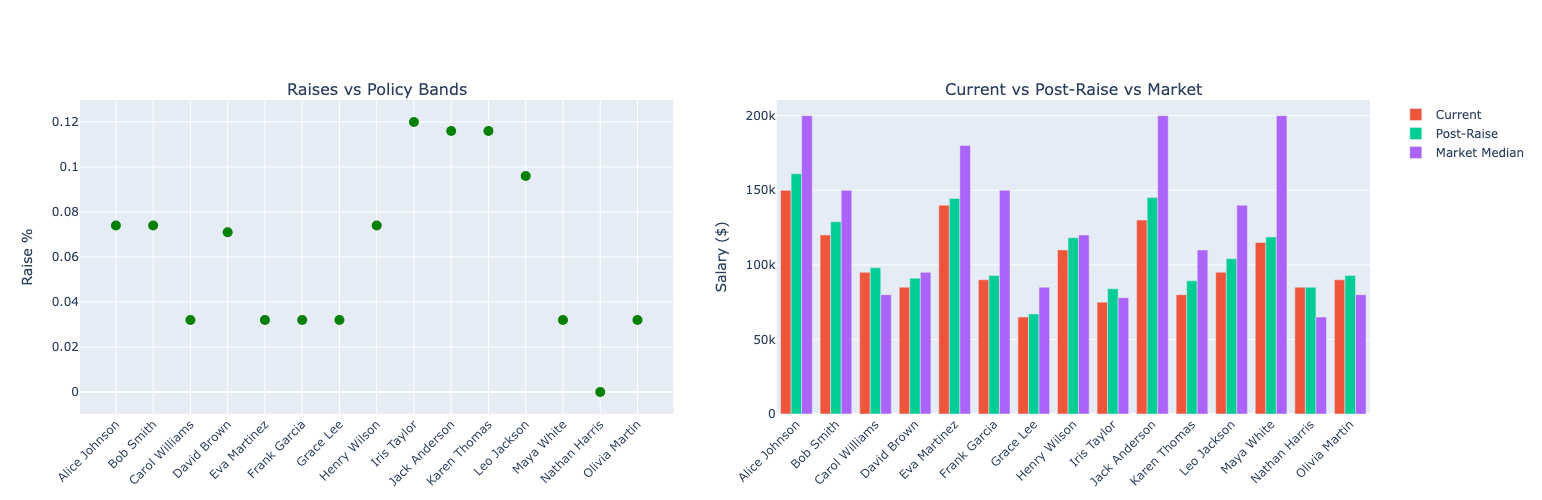

In [9]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- Load both tables ---
pc = _constat_session.table("policy_comparison", pandas=True)
mc = _constat_session.table("market_comparison", pandas=True)

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Raises vs Policy Bands", "Current vs Post-Raise vs Market"),
    horizontal_spacing=0.08,
)

# --- Left: Policy comparison scatter ---
pc_name = next((c for c in pc.columns if "name" in c.lower()), pc.columns[0])
pc_rating = next((c for c in pc.columns if "rating" in c.lower()), None)
pc_raise = next((c for c in pc.columns if "raise" in c.lower() and "pct" in c.lower()), None)
pc_min = next((c for c in pc.columns if "min" in c.lower()), None)
pc_max = next((c for c in pc.columns if "max" in c.lower()), None)
pc_flag = next((c for c in pc.columns if "range" in c.lower() or "flag" in c.lower()), None)

if all([pc_rating, pc_raise, pc_min, pc_max]):
    for rating in sorted(pc[pc_rating].unique()):
        sub = pc[pc[pc_rating] == rating]
        lo, hi = sub[pc_min].iloc[0], sub[pc_max].iloc[0]
        fig.add_hrect(
            y0=lo, y1=hi, fillcolor="green", opacity=0.08,
            annotation_text=f"Rating {rating}: {lo}-{hi}%",
            annotation_position="top left",
            row=1, col=1,
        )
    colors = ["green" if v else "red" for v in pc[pc_flag]] if pc_flag else "steelblue"
    fig.add_trace(go.Scatter(
        x=pc[pc_name], y=pc[pc_raise],
        mode="markers", marker=dict(size=10, color=colors),
        text=pc.apply(lambda r: f"Rating: {r[pc_rating]}, Raise: {r[pc_raise]:.1f}%", axis=1),
        hoverinfo="text+x", showlegend=False,
    ), row=1, col=1)
    fig.update_xaxes(tickangle=-45, row=1, col=1)
    fig.update_yaxes(title_text="Raise %", row=1, col=1)

# --- Right: Market comparison grouped bars ---
mc_name = next((c for c in mc.columns if "name" in c.lower()), mc.columns[0])
mc_curr = next((c for c in mc.columns if "current" in c.lower() and "sal" in c.lower()), None)
mc_new = next((c for c in mc.columns if "new" in c.lower() and "sal" in c.lower()), None)
mc_market = next((c for c in mc.columns if "market" in c.lower() and "median" in c.lower()), None)

if all([mc_curr, mc_new, mc_market]):
    fig.add_trace(go.Bar(name="Current", x=mc[mc_name], y=mc[mc_curr]), row=1, col=2)
    fig.add_trace(go.Bar(name="Post-Raise", x=mc[mc_name], y=mc[mc_new]), row=1, col=2)
    fig.add_trace(go.Bar(name="Market Median", x=mc[mc_name], y=mc[mc_market]), row=1, col=2)
    fig.update_xaxes(tickangle=-45, row=1, col=2)
    fig.update_yaxes(title_text="Salary ($)", row=1, col=2)

fig.update_layout(height=500, width=1200, barmode="group")
fig.show()

## Raise Distribution

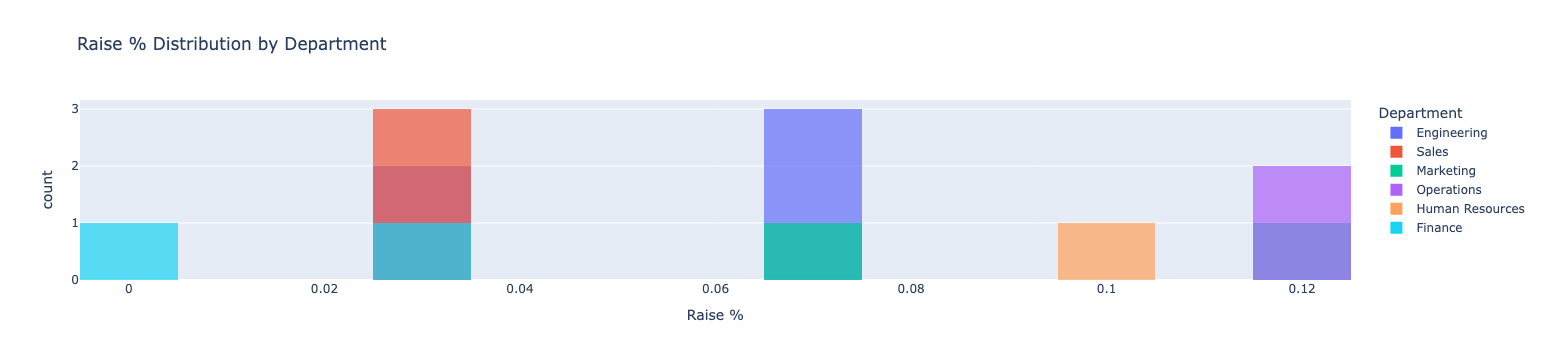

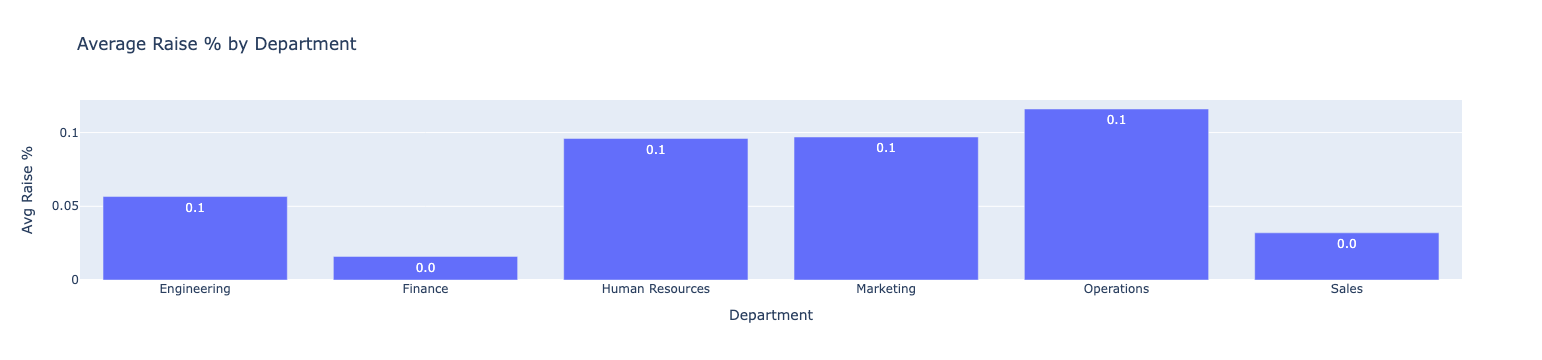

In [10]:
import plotly.express as px

df = _constat_session.table("raise_recommendations", pandas=True)

pct_col = next((c for c in df.columns if "raise" in c.lower() and "pct" in c.lower()), None)
dept_col = next((c for c in df.columns if "dept" in c.lower() or "department" in c.lower()), None)

if pct_col and dept_col:
    fig = px.histogram(
        df, x=pct_col, color=dept_col, nbins=15,
        title="Raise % Distribution by Department",
        labels={pct_col: "Raise %", dept_col: "Department"},
        barmode="overlay", opacity=0.7,
    )
    fig.show()

    avg = df.groupby(dept_col)[pct_col].mean().reset_index()
    fig2 = px.bar(
        avg, x=dept_col, y=pct_col,
        title="Average Raise % by Department",
        labels={pct_col: "Avg Raise %", dept_col: "Department"},
        text_auto=".1f",
    )
    fig2.show()
else:
    print(f"Expected columns not found. Available: {list(df.columns)}")

## Executive Summary

Generate a CFO-ready summary with budget impact and department breakdown.

In [11]:
%%constat auto include:md

Create an executive summary of the raise recommendations
for CFO approval. Include total budget impact, department
breakdown, and distribution by raise percentage tier.

**Answer:** Recommend approving a total raise budget of $95,675 (6.2% average) across 15 employees, with Operations receiving the highest investment due to retention priorities.

**Key Insight:** Raise distribution is strategically skewed toward Operations (11.6% avg) and Marketing (9.7% avg), while Finance receives minimal increases (1.6% avg). This pattern suggests targeted retention efforts in high-turnover or specialized roles, though the Finance department's minimal raises warrants clarification on whether this reflects performance tiers or resource constraints.

**Next Steps:**
1. What is the rationale for the significant disparity between Operations/Marketing and Finance raise percentages—does this align with market benchmarking data?
2. Should Finance's 1.6% average be reviewed to ensure competitiveness and prevent talent attrition?
3. Are there equity concerns with Engineering's mid-range 5.7% raise, given its 5-person headcount and criticality to operations?

## Employee Communications

Generate personalized raise announcement emails. The `published` flag
displays only starred (key result) tables.

In [12]:
%%constat auto published

Generate a personalized email communication for each employee
announcing their raise. Save to a table called employee_emails
with columns: employee_name, email_address, html_email_body

**Answer:** The personalized raise announcement emails have been generated in the `employee_emails` table, ready for distribution to all 15 employees.

**Key Insight:** There is a critical policy compliance issue—all 15 employees have raises outside their compensation policy ranges, indicating a systematic misalignment between the raise recommendations and established merit guidelines. This suggests either the policy guidelines need revision, the rating system requires recalibration, or the recommendations should be adjusted before emails are sent.

**Next Steps:**
1. Should we pause the email distribution until compensation policy guidelines are realigned with the raise recommendations?
2. Which department's raises show the largest deviation from policy, and should that be prioritized for review?
3. Do the policy ranges in the compensation_policy document accurately reflect current organizational compensation strategy?

In [13]:
# Preview email table and sample
df = _constat_session.table("employee_emails")
print(f"employee_emails: {len(df)} rows")
display(df.head(5))

row = df.to_pandas().iloc[0]
html_col = next((c for c in row.index if "html" in c.lower() and "body" in c.lower()), None)
if html_col:
    from IPython.display import HTML
    display(HTML(f"<h4>Sample email for {row.iloc[0]}:</h4>"))
    display(HTML(row[html_col]))

employee_emails: 15 rows


employee_name,email_address,html_email_body
"""Alice Johnson""","""alice.johnson@company.com""","""<html> <head> <sty…"
"""Bob Smith""","""bob.smith@company.com""","""<html> <head> <sty…"
"""Carol Williams""","""carol.williams@company.com""","""<html> <head> <sty…"
"""David Brown""","""david.brown@company.com""","""<html> <head> <sty…"
"""Olivia Martin""","""olivia.martin@company.com""","""<html> <head> <sty…"


## Export for Mail Merge

In [14]:
df = _constat_session.table("employee_emails", pandas=True)
df.to_csv("raise_emails.csv", index=False)
print(f"Exported {len(df)} emails to raise_emails.csv")

Exported 15 emails to raise_emails.csv
